In [23]:
print("Hello, World!")

Hello, World!


In [24]:
from dotenv import load_dotenv
import os

# Force reload and check if it loaded
result = load_dotenv("/Users/rajarshiray/Documents/Projects/agentic-ai-crash-course/.env")
print(f"load_dotenv result: {result}")
print(f"OPENAI_API_KEY: {os.getenv('OPENAI_API_KEY')}")

# If still None, try this workaround:
if os.getenv("OPENAI_API_KEY") is None:
    with open("/Users/rajarshiray/Documents/Projects/agentic-ai-crash-course/.env") as f:
        for line in f:
            key, value = line.strip().split("=")
            os.environ[key] = value
    print(f"After manual load: {os.getenv('OPENAI_API_KEY')}")

load_dotenv result: True
OPENAI_API_KEY: REMOVED


In [25]:
with open("/Users/rajarshiray/Documents/Projects/agentic-ai-crash-course/.env") as f:
    content = f.read()
    print(f"Raw file content: {repr(content)}")
    print(f"File length: {len(content)}")
    
    # Check each line
    for i, line in enumerate(content.split("\n")):
        print(f"Line {i}: {repr(line)}")

Raw file content: 'OPENAI_API_KEY="REMOVED"'
File length: 181
Line 0: 'OPENAI_API_KEY="REMOVED"'


In [26]:
from langchain_openai import ChatOpenAI

In [27]:
chat_llm = ChatOpenAI(model="gpt-4o-mini")

In [28]:
chat_llm.invoke("What is the capital of France?").content

'The capital of France is Paris.'

In [29]:
from typing_extensions import TypedDict, Annotated
import operator
from langchain_core.messages import AnyMessage, HumanMessage, AIMessage

In [30]:
class GraphState(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]

In [31]:
def llm_call(state: GraphState) -> dict:
    response = chat_llm.invoke(state["messages"])
    return {"messages": state["messages"] + [response]}

In [32]:
def token_counter(state: GraphState) -> dict:
    """Count tokens (simple word count) in the last AI message."""
    last_msg = state["messages"][-1]
    text = last_msg.content
    token_number = len(text.split())
    summary = f"Total token number in the generated answer (word count) is {token_number}"
    return {
        "messages": [AIMessage(content=summary)]
    }

In [33]:
from langgraph.graph import StateGraph

In [34]:
builder = StateGraph(GraphState)

In [35]:
builder.add_node("llm_call", llm_call)
builder.add_node("token_counter", token_counter)


In [36]:
builder.set_entry_point("llm_call")
builder.add_edge("llm_call", "token_counter")
builder.set_finish_point("token_counter")

In [37]:
app = builder.compile()

In [38]:
app.get_graph()

Graph(nodes={'__start__': Node(id='__start__', name='__start__', data=RunnableCallable(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'llm_call': Node(id='llm_call', name='llm_call', data=llm_call(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'token_counter': Node(id='token_counter', name='token_counter', data=token_counter(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), '__end__': Node(id='__end__', name='__end__', data=None, metadata=None)}, edges=[Edge(source='__start__', target='llm_call', data=None, conditional=False), Edge(source='llm_call', target='token_counter', data=None, conditional=False), Edge(source='token_counter', target='__end__', data=None, conditional=False)])

In [39]:
from IPython.display import Image, display

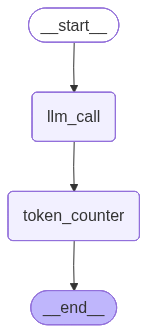

In [40]:
display(Image(app.get_graph().draw_mermaid_png()))

In [41]:
result = app.invoke({"messages": [HumanMessage(content="What is the capital of France?")]})
print(result["messages"][-1].content)

Total token number in the generated answer (word count) is 6


In [42]:
for m in result["messages"]:
    print(type(m).__name__, ":", m.content)

HumanMessage : What is the capital of France?
HumanMessage : What is the capital of France?
AIMessage : The capital of France is Paris.
AIMessage : Total token number in the generated answer (word count) is 6


In [43]:
chat_llm

ChatOpenAI(profile={'max_input_tokens': 128000, 'max_output_tokens': 16384, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'structured_output': True, 'image_url_inputs': True, 'pdf_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x1100f68a0>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x11010d250>, root_client=<openai.OpenAI object at 0x11010bb60>, root_async_client=<openai.AsyncOpenAI object at 0x1100f5cd0>, model_name='gpt-4o-mini', model_kwargs={}, openai_api_key=SecretStr('**********'), stream_usage=True)

In [46]:
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper

In [47]:
api_wrapper = WikipediaAPIWrapper(top_k_results=5, doc_content_chars_max=500)

In [48]:
wiki_tool = WikipediaQueryRun(api_wrapper=api_wrapper)

In [49]:
wiki_tool.run({"query": "Generative AI"})

'Page: Generative artificial intelligence\nSummary: Generative artificial intelligence, also known as generative AI or GenAI, is a subfield of artificial intelligence that uses generative models to generate text, images, videos, audio, software code or other forms of data. These models learn the underlying patterns and structures of their training data, and use them to generate new data in response to input, which often takes the form of natural language prompts.\nThe prevalence of generative AI to'

'Page: Generative artificial intelligence\nSummary: Generative artificial intelligence, also known as generative AI or GenAI, is a subfield of artificial intelligence that uses generative models to generate text, images, videos, audio, software code or other forms of data. These models learn the underlying patterns and structures of their training data, and use them to generate new data in response to input, which often takes the form of natural language prompts.\nThe prevalence of generative AI to'

In [1]:
import os
from langchain_community.tools.tavily_search import TavilySearchResults

TAVILY_API_KEY = os.getenv("TAVILY_API_KEY")

In [2]:
TAVILY_API_KEY

'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'

In [3]:
tool = TavilySearchResults(api_key=TAVILY_API_KEY)

/var/folders/ln/2r0y155n0hl7k61ty35cjdjc0000gn/T/ipykernel_67565/3716120651.py:1: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tool = TavilySearchResults(api_key=TAVILY_API_KEY)


In [4]:
tool.invoke({"query": "What is the latest news on Generative AI?"})

[{'title': 'Generative AI news and analysis',
  'url': 'https://techcrunch.com/tag/generative-ai/',
  'content': 'Crunchboard\n\nContact Us\n\n# Generative AI\n\nTechCrunch covers the latest news and analysis in Generative AI (GenAI). Read the latest on startups and founders building artificial intelligence tools. From OpenAI with ChatGPT, to Google with Gemini—TechCrunch covers the entire ecosystem.\n\n### \n\nSpotify logo\n\n### Spotify says its best developers haven’t written a line of code since December, thanks to AI\n\nscene from House of David\n\n### Amazon to begin testing AI tools for film and TV production next month\n\nRoblox 4D\n\n### Roblox’s 4D creation feature is now available in open beta\n\nMozilla/Firefox logo\n\n### Firefox will soon let you block all of its generative AI features\n\n### Node-based design tool Flora raises $42M from Redpoint Ventures\n\nImage of a user prompting the new Slackbot interface. [...] Save up to $680 on your pass with Super Early Bird rate

In [10]:
from langchain_community.tools import DuckDuckGoSearchResults
search = DuckDuckGoSearchResults()

In [11]:
search.invoke("What is the latest news on iphone17")

"snippet: 4 days ago · ... News & Rumors site on the Internet. Welcome to MacRumors, your ultimate ... Plus, we break down the latest iPhone 17e rumors including MagSafe support ..., title: One Year With This iPhone — What Still Bugs Me + New 17e Rumors - YouTube, link: https://www.youtube.com/watch?v=oaDbNoiJ0zI, snippet: 3 days ago · Apple's new iPhone 17 typically costs $830 for the 256GB configuration, or up to $1,030 for the 512GB configuration. However, T-Mobile is offering it to ..., title: Let T-Mobile Pick Up the Tab. Get a Free iPhone 17 With a New Line - CNET, link: https://www.cnet.com/deals/t-mobile-free-iphone-17-deal/, snippet: Aug 11, 2025 · Apple is expected to unveil the iPhone 17 lineup on Sept. 9, with leaks pointing to design changes, upgraded cameras, and possible price increases for the ..., title: Apple iPhone 17 series: What to know about the release date, cost and features, link: https://www.livenowfox.com/news/apple-iphone-17-release-date-price-features, snip

In [12]:
from langchain_community.tools import YouTubeSearchTool

In [14]:
tool = YouTubeSearchTool()

In [15]:
tool.name

'youtube_search'

In [16]:
tool.description

'search for youtube videos associated with a person. the input to this tool should be a comma separated list, the first part contains a person name and the second a number that is the maximum number of video results to return aka num_results. the second part is optional'

'search for youtube videos associated with a person. the input to this tool should be a comma separated list, the first part contains a person name and the second a number that is the maximum number of video results to return aka num_results. the second part is optional'

In [18]:
tool.run("Rajarshi Ray Guitar")

"['https://www.youtube.com/watch?v=RW28GYXzsRU&list=RDRW28GYXzsRU&start_radio=1&pp=ygUTUmFqYXJzaGkgUmF5IEd1aXRhcqAHAQ%3D%3D', 'https://www.youtube.com/watch?v=eKck7B5aNG4&list=RDeKck7B5aNG4&start_radio=1&pp=ygUTUmFqYXJzaGkgUmF5IEd1aXRhcqAHAQ%3D%3D']"

In [19]:
def multiply(a: int, b: int) -> int:
    return a * b

In [20]:
multiply(3, 4)

12

In [21]:
from langchain.tools import tool
@tool
def multiply(a: int, b: int) -> int:
    """Multiplies two numbers."""
    return a * b

In [23]:
multiply.invoke({"a": 3, "b": 4})

12

In [24]:
@tool
def get_word_length(word: str) -> int:
    """Returns the length of the given word."""
    return len(word)

In [26]:
get_word_length.invoke("Generative AI")

13

In [28]:
import yfinance as yf

In [29]:
@tool
def get_stock_price(ticker:str) -> str: 
    """this is a tool to get stock price using yfinance"""
    try:
        stock = yf.Ticker(ticker)

        # Get last 1 day historical data
        data = stock.history(period="1d")

        if data.empty:
            return f"No data found for ticker '{ticker}'. Please check the symbol."

        latest_close = data["Close"].iloc[-1]

        # Detect currency
        currency = stock.info.get("currency", "")
        symbol_map = {
            "INR": "₹",
            "USD": "$",
            "EUR": "€",
            "GBP": "£"
        }

        symbol = symbol_map.get(currency, "")
        currency_text = currency if currency else ""

        if symbol:
            return f"The last closing price of {ticker.upper()} was {symbol}{latest_close:.2f}."
        else:
            return f"The last closing price of {ticker.upper()} was {latest_close:.2f} {currency_text}."

    except Exception as e:
        return f"An error occurred while fetching stock data: {str(e)}"

In [30]:
get_stock_price.invoke({"ticker": "AAPL"})

'The last closing price of AAPL was $266.18.'